In [21]:
import glob

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from scipy.stats import genextreme as gev
from scipy import stats
import xclim as xc
from xclim import sdba
from xclim.sdba import nbutils

from unseen import fileio
from unseen import eva
from unseen import bias_correction
from unseen import time_utils
from unseen import stability

In [2]:
lat = {}
lon = {}

lat['Katherine'] = -14.5
lon['Katherine'] = 132.3

lat['Surat'] = -27.2
lon['Surat'] = 149.1

lat['Miena'] = -42.0
lon['Miena'] = 146.7

In [3]:
location = 'Katherine'

## Observations

In [22]:
def get_obs_data(metric):
    """Get obs data"""

    var = {'txx': 'tasmax', 'rx1day': 'pr'}
    
    obs_file = glob.glob(f'/g/data/xv83/unseen-projects/outputs/bias/data/{metric}_AGCD-CSIRO_*_AUS300i.nc')[0]
    ds_obs = fileio.open_dataset(obs_file)
    da_obs = ds_obs[var[metric]].sel({'lat': lat[location], 'lon': lon[location]}, method='nearest')
    da_obs = da_obs.compute()

    return da_obs


def detrend_obs(da_obs):
    """Linearly detrend obs data."""

    linear_fit_obs = np.polyfit(da_obs.time.dt.year.values, da_obs.values, 1)
    linear_data_obs = np.polyval(linear_fit_obs, da_obs.time.dt.year.values)
    base_mean_obs = da_obs.sel(time=slice('1972-01-01', '2018-12-31')).mean().values
    da_obs_detrended = (da_obs - linear_data_obs) + base_mean_obs
    da_obs_detrended.attrs = da_obs.attrs

    return da_obs_detrended

## Model data

In [47]:
model_dict = {
    'BCC-CSM2-MR': 'tab:blue',
    'CAFE': 'tab:orange',
#    'CMCC-CM2-SR5': 'tab:green',
    'CanESM5': 'tab:red',
    'EC-Earth3': 'tab:purple',
    'IPSL-CM6A-LR': 'tab:brown',
    'MIROC6': 'tab:pink',
    'MPI-ESM1-2-HR': 'tab:grey',
    'MRI-ESM2-0': 'tab:olive',
    'NorCPM1': 'tab:cyan',
}   

In [34]:
def get_model_data(metric, model):
    """Get grid point data for a single metric/model combination"""

    var = {'txx': 'tasmax', 'rx1day': 'pr'}
    model_file = glob.glob(f'/g/data/xv83/unseen-projects/outputs/bias/data/{metric}_{model}-*_*_annual-jul-to-jun_AUS300i.nc')[0]
    ds_model = fileio.open_dataset(model_file)
    da_model = ds_model[var[metric]].sel({'lat': lat[location], 'lon': lon[location]}, method='nearest')
    da_model = da_model.compute()
    da_model_stacked = da_model.dropna('lead_time').stack({'sample': ['ensemble', 'init_date', 'lead_time']})

    return da_model_stacked


def detrend_model(da_model_stacked):
    """linearly detrend model data."""

    linear_fit_model = np.polyfit(da_model_stacked.time.dt.year.values, da_model_stacked.values, 1)
    linear_data_model = np.polyval(linear_fit_model, np.unique(da_model_stacked.time.dt.year.values))
    da_model_stacked_base = time_utils.select_time_period(da_model_stacked.copy(), ['1972-01-01', '2018-12-31'])
    base_mean_model = da_model_stacked_base.mean().values
    value_year_pairs = np.column_stack((da_model_stacked.values, da_model_stacked.time.dt.year.values))
    detrended_data = []
    for value, year in value_year_pairs:
        af = np.polyval(linear_fit_model, year)
        detrended_value = value - af + base_mean_model
        detrended_data.append(detrended_value)
    detrended_data = np.array(detrended_data)
    da_model_detrended_stacked = da_model_stacked * 0 + detrended_data
    da_model_detrended_stacked.attrs = da_model_stacked.attrs

    return da_model_detrended_stacked

In [44]:
def mean_correction(da_model_detrended, da_obs_detrended, method):
    """Apply a mean correction."""

    assert method in ['additive', 'multiplicative']
    
    bias = bias_correction.get_bias(
        da_model_detrended,
        da_obs_detrended,
        method,
        time_rounding='A',
        time_period=['1972-01-01', '2018-12-31']
    )
    da_model_detrended_bc = bias_correction.remove_bias(da_model_detrended, bias, method)
    da_model_detrended_bc = da_model_detrended_bc.compute()
    da_model_detrended_bc_stacked = da_model_detrended_bc.dropna('lead_time').stack(
        {'sample': ['ensemble', 'init_date', 'lead_time']}
    )

    return da_model_detrended_bc_stacked

In [45]:
def get_smooth_adjustment_factor(value, data, af_cubic_fit):
    """Find the adjustment factor."""

    quantile = stats.percentileofscore(data, value) / 100
    af = np.polyval(af_cubic_fit, quantile)

    return af


vget_smooth_adjustment_factor = np.vectorize(get_smooth_adjustment_factor, excluded=['data', 'af_cubic_fit'])


def quantile_correction(da_model_detrended_stacked, da_obs_detrended, method):
    """Apply a mean correction."""

    assert method in ['additive', 'multiplicative']

    nquantiles = 10
    quantile_array = xc.sdba.utils.equally_spaced_nodes(nquantiles)
    da_model_detrended_q = nbutils.quantile(
        da_model_detrended_stacked,
        quantile_array,
        ['sample']
    )
    da_obs_detrended_q = nbutils.quantile(
        da_obs_detrended,
        quantile_array,
        ['time']
    )

    if method == 'additive':
        bias = da_model_detrended_q.values - da_obs_detrended_q.values
    elif method == 'multiplicative':
        bias = da_model_detrended_q.values / da_obs_detrended_q.values
    bias_cubic_fit = np.polyfit(quantile_array, bias, 3)
    
    af = vget_smooth_adjustment_factor(
        da_model_detrended_stacked.values,
        data=da_model_detrended_stacked.values,
        af_cubic_fit=bias_cubic_fit,
    )
    if method == 'additive':
        da_model_detrended_stacked_bc = da_model_detrended_stacked - af
    elif method == 'multiplicative':
        da_model_detrended_stacked_bc = da_model_detrended_stacked / af

    return da_model_detrended_stacked_bc

## TXx

In [24]:
metric = 'txx'

In [25]:
da_obs = get_obs_data(metric)
da_obs_detrended = detrend_obs(da_obs)
gev_shape_obs_detrended, gev_loc_obs_detrended, gev_scale_obs_detrended = eva.fit_gev(da_obs_detrended.values)

In [48]:
da_model_dict = {}
gev_model_dict = {}
method = 'multiplicative' if metric == 'rx1day' else 'additive'
for model in model_dict:
    print(model)
    da_model_stacked = get_model_data(metric, model)
    da_model_detrended_stacked = detrend_model(da_model_stacked)
    da_model_detrended = da_model_detrended_stacked.unstack()
    da_model_detrended_stacked_bc_mean = mean_correction(da_model_detrended, da_obs_detrended, method)
    da_model_detrended_stacked_bc_quantile = quantile_correction(da_model_detrended_stacked, da_obs_detrended, method)

    da_model_dict[('raw', model)] = da_model_detrended_stacked
    da_model_dict[('bc-mean', model)] = da_model_detrended_stacked_bc_mean
    da_model_dict[('bc-quantile', model)] = da_model_detrended_stacked_bc_quantile
    
    gev_model_dict[('raw', model)] = eva.fit_gev(da_model_detrended_stacked.values)
    gev_model_dict[('bc-mean', model)] = eva.fit_gev(da_model_detrended_stacked_bc_mean.values)
    gev_model_dict[('bc-quantile', model)] = eva.fit_gev(da_model_detrended_stacked_bc_quantile.values)

BCC-CSM2-MR
CAFE
CanESM5
EC-Earth3
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MRI-ESM2-0
NorCPM1


BCC-CSM2-MR
CAFE
CanESM5
EC-Earth3
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MRI-ESM2-0
NorCPM1


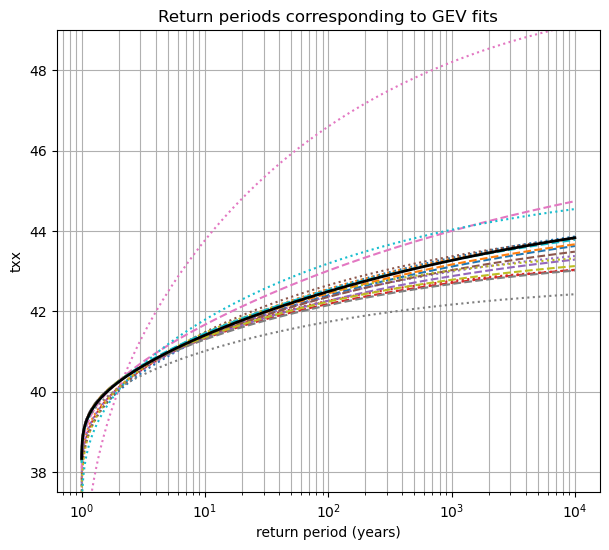

In [62]:
fig = plt.figure(figsize=[7, 6])
ax = fig.add_subplot(111)

for model, color in model_dict.items():
    print(model)
    # Model (raw)
#    return_periods_model_raw, return_values_model_raw = stability.return_curve(
#        da_model_dict[('raw', model)],
#        'gev',
#        params=list(gev_model_dict[('raw', model)]),
#    )
#    ax.plot(return_periods_model_raw, return_values_model_raw, label=f'{model} (raw)', color=color)
    
    # Model (mean correction)
    return_periods_model_bc_mean, return_values_model_bc_mean = stability.return_curve(
        da_model_dict[('bc-mean', model)],
        'gev',
        params=list(gev_model_dict[('bc-mean', model)]),
    )
    ax.plot(
        return_periods_model_bc_mean,
        return_values_model_bc_mean,
        label=f'{model} (mean correction, {method})',
        color=color,
        linestyle=':',
    )
    
    # Model (quantile correction)
    return_periods_model_bc_quantile, return_values_model_bc_quantile = stability.return_curve(
        da_model_dict[('bc-quantile', model)],
        'gev',
        params=list(gev_model_dict[('bc-quantile', model)]),
    )
    ax.plot(
        return_periods_model_bc_quantile,
        return_values_model_bc_quantile,
        label=f'{model} (quantile correction, {method})',
        color=color,
        linestyle='--',
    )
    
# Observations
return_periods_obs_detrended, return_values_obs_detrended = stability.return_curve(
    da_obs_detrended,
    'gev',
    params=[gev_shape_obs_detrended, gev_loc_obs_detrended, gev_scale_obs_detrended],
)
ax.plot(return_periods_obs_detrended, return_values_obs_detrended, label='AGCD', color='black', linewidth=2.0)
    
#ax.legend()
ax.set_xscale('log')
ax.set_xlabel('return period (years)')
ax.set_ylabel(f'{metric}')
ax.set_title('Return periods corresponding to GEV fits')
if metric == 'rx1day':
    ax.set_ylim([0, 300])
elif metric == 'txx':
    ax.set_ylim([37.5, 49])
ax.grid(which='both')
#plt.savefig(f'rx1day_{location}_return_curves.png', bbox_inches='tight', facecolor='white')
plt.show()